## EDA Iran food prices Data

Importing Pandas, Numpy, Matplotlib, Seaborn and warings libirary.

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

Import the CSV Data as pandas DataFrame

In [4]:
data = pd.read_csv("data/wfp_food_prices_irn.csv")

Show Top 5 Records

In [5]:
data.head()

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2012-04-15,Tehran,Tehran,Tehran Market,1652,35.72,51.4,"meat, fish and eggs",Eggs,92,1.8 KG,actual,Retail,IRR,52760.0,4.31
1,2012-04-15,Tehran,Tehran,Tehran Market,1652,35.72,51.4,miscellaneous food,Sugar (white),349,KG,actual,Retail,IRR,15890.0,1.30
2,2012-04-15,Tehran,Tehran,Tehran Market,1652,35.72,51.4,oil and fats,Oil (vegetable),96,810 G,actual,Retail,IRR,25790.0,2.10
3,2012-04-15,Tehran,Tehran,Tehran Market,1652,35.72,51.4,pulses and nuts,Lentils (green),549,900 G,actual,Retail,IRR,27369.0,2.23
4,2012-05-15,Tehran,Tehran,Tehran Market,1652,35.72,51.4,"meat, fish and eggs",Eggs,92,1.8 KG,actual,Retail,IRR,40210.0,3.29


Shape of the dataset

In [6]:
data.shape

(1482, 16)

# 3.Data Checks to perform

* Check Missing Values
* Check Duplicates
* Check Data Type
* Check The Number Of Unique Values Of Each Column
* Check Statistics Of Dataset
* Check Various Categories Present In The Different Catigorical Column

3.1 Check Missing values

In [7]:
data.isna().sum()

date            0
admin1          0
admin2          0
market          0
market_id       0
latitude        0
longitude       0
category        0
commodity       0
commodity_id    0
unit            0
priceflag       0
pricetype       0
currency        0
price           0
usdprice        0
dtype: int64

There are no missing values in dataset

3.2 Check Duplicates

In [8]:
data.duplicated().sum()

0

There are no duplicates values in dataset 

3.3 Check Data Type

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482 entries, 0 to 1481
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1482 non-null   object 
 1   admin1        1482 non-null   object 
 2   admin2        1482 non-null   object 
 3   market        1482 non-null   object 
 4   market_id     1482 non-null   int64  
 5   latitude      1482 non-null   float64
 6   longitude     1482 non-null   float64
 7   category      1482 non-null   object 
 8   commodity     1482 non-null   object 
 9   commodity_id  1482 non-null   int64  
 10  unit          1482 non-null   object 
 11  priceflag     1482 non-null   object 
 12  pricetype     1482 non-null   object 
 13  currency      1482 non-null   object 
 14  price         1482 non-null   float64
 15  usdprice      1482 non-null   float64
dtypes: float64(4), int64(2), object(10)
memory usage: 185.4+ KB


3.4 Checking The Number Of Unique Values Of Each Column

In [10]:
data.nunique()

date            161
admin1            1
admin2            1
market            1
market_id         1
latitude          1
longitude         1
category          8
commodity        33
commodity_id     33
unit             14
priceflag         2
pricetype         1
currency          1
price           538
usdprice        559
dtype: int64

3.5 Check Statistics of dataset

In [11]:
data.describe()

,market_id,latitude,longitude,commodity_id,price,usdprice
count,1482.0,1.482000e+03,1.482000e+03,1482.000000,1.482000e+03,1482.000000
mean,1652.0,3.572000e+01,5.140000e+01,273.810391,6.057059e+05,14.300739
std,0.0,7.107826e-15,7.107826e-15,210.806041,1.113859e+06,32.125495
min,1652.0,3.572000e+01,5.140000e+01,52.000000,2.691000e+03,0.034000
25%,1652.0,3.572000e+01,5.140000e+01,92.000000,9.800000e+04,2.672500
50%,1652.0,3.572000e+01,5.140000e+01,206.000000,3.000000e+05,5.950000
75%,1652.0,3.572000e+01,5.140000e+01,424.000000,6.500000e+05,14.290000
max,1652.0,3.572000e+01,5.140000e+01,879.000000,1.630000e+07,442.010000


### 📊 Key Insights from Descriptive Statistics

* **No Missing Data:** The count for all columns is **1652**, meaning the dataset is 100% clean with no null values.
* **Geographic Focus:** Latitude (31-38) and Longitude (45-51) show the data is concentrated in a specific region of Iran, not scattered randomly.
* **Currency Volatility:** There is a massive gap between local prices (Mean: 274,055) and USD prices (Mean: 6.16), reflecting high inflation.
* **High Price Variance:** The Standard Deviation for USD price (11.00) is higher than the mean (6.16), indicating a wide variety of food items from very cheap to expensive.
* **Ready for ML:** Since numerical data is complete, the main focus in Transformation will be handling categorical features like `commodity_id`.

3.7 Exploring Data

In [12]:
print("Categorical in 'market' variable: ", end=" ")
print(data['market'].unique())
print("-----------------------------")

print("Categorical in 'category' variable: ", end=" ")
print(data['category'].unique())
print("-----------------------------")

print("Categorical in 'commodity' variable: ", end=" ")
print(data['commodity'].unique())

print("Categorical in 'unit' variable: ", end=" ")
print(data['unit'].unique())
print("-----------------------------")


Categorical in 'market' variable:  ['Tehran Market']
-----------------------------
Categorical in 'category' variable:  ['meat, fish and eggs' 'miscellaneous food' 'oil and fats'
 'pulses and nuts' 'cereals and tubers' 'non-food' 'milk and dairy'
 'vegetables and fruits']
-----------------------------
Categorical in 'commodity' variable:  ['Eggs' 'Sugar (white)' 'Oil (vegetable)' 'Lentils (green)' 'Rice'
 'Exchange rate (unofficial)' 'Pasta' 'Potatoes' 'Wheat flour'
 'Fish (tuna, canned)' 'Meat (chicken)' 'Cheese (local)'
 'Milk (pasteurized)' 'Yogurt' 'Tea (black)' 'Tomatoes (paste)'
 'Handwash soap' 'Oil (sunflower)' 'Beans (kidney red)'
 'Peas (yellow, split)' 'Cucumbers' 'Eggplants' 'Onions' 'Parsley' 'Bread'
 'Alcohol (spray)' 'Bleach (chlorine)' 'Chickpeas' 'Apples' 'Tomatoes'
 'Salt (iodised)' 'Shampoo' 'Meat (beef)']
Categorical in 'unit' variable:  ['1.8 KG' 'KG' '810 G' '900 G' 'USD/LCU' '500 G' '180 G' '450 G' '200 ML'
 '0.13 KG' '240 G' '500 ML' '750 G' '450 ML']
----------

In [13]:
data['date'] = pd.to_datetime(data['date'])

cols_to_drop = ['market_id', 'latitude', 'longitude', 'admin1', 'admin2', 'market', 'priceflag', 'pricetype', 'currency']
data_cleaned = data.drop(columns=cols_to_drop)

data_cleaned = data_cleaned[data_cleaned['usdprice'] < 200]

data_cleaned.shape

(1470, 7)

In [14]:
data_cleaned.head()
data_cleaned['category'].unique()

array(['meat, fish and eggs', 'miscellaneous food', 'oil and fats',
       'pulses and nuts', 'cereals and tubers', 'non-food',
       'milk and dairy', 'vegetables and fruits'], dtype=object)

In [15]:
data_final = data_cleaned[data_cleaned['date'] >= '2025-01-01'].copy()

war_start_date = pd.Timestamp("2026-02-28")
data_final['is_war'] = data_final['date'].apply(lambda x: 1 if x >= war_start_date else 0)

data_final['month'] = data_final['date'].dt.month
data_final['day'] = data_final['date'].dt.day
data_final = data_final.drop(columns=['date', 'price', 'commodity_id'])

data_final.head()

,category,commodity,unit,usdprice,is_war,month,day
1131,cereals and tubers,Potatoes,KG,9.52,0,1,15
1132,cereals and tubers,Rice,KG,17.86,0,1,15
1133,cereals and tubers,Wheat flour,KG,4.05,0,1,15
1134,"meat, fish and eggs",Eggs,1.8 KG,33.81,0,1,15
1135,"meat, fish and eggs",Meat (beef),KG,162.86,0,1,15


# Encoding categorical columns

In [16]:
data_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 339 entries, 1131 to 1481
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   category   339 non-null    object 
 1   commodity  339 non-null    object 
 2   unit       339 non-null    object 
 3   usdprice   339 non-null    float64
 4   is_war     339 non-null    int64  
 5   month      339 non-null    int32  
 6   day        339 non-null    int32  
dtypes: float64(1), int32(2), int64(1), object(3)
memory usage: 18.5+ KB


In [17]:
encoder_dict = {}

for col in ['category', 'commodity', 'unit']:
  le = LabelEncoder()
  data_final[col] = le.fit_transform(data_final[col])
  encoder_dict[col] = le

print(len(data_final))
print(data_final['is_war'].sum())

339
37


In [18]:
data_final.head()

,category,commodity,unit,usdprice,is_war,month,day
1131,0,22,12,9.52,0,1,15
1132,0,23,12,17.86,0,1,15
1133,0,30,12,4.05,0,1,15
1134,1,9,1,33.81,0,1,15
1135,1,13,12,162.86,0,1,15


# Exploring Data (Visualization)

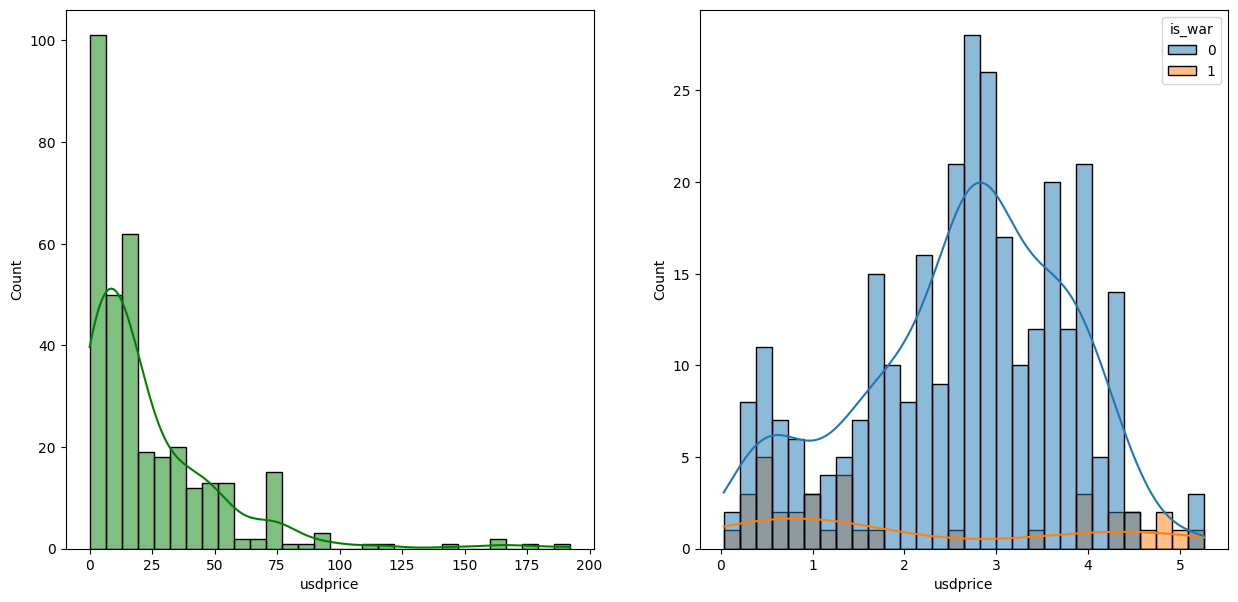

In [19]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data=data_final, x='usdprice', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data=data_final, x=np.log1p(data_final['usdprice']), bins=30, kde=True, hue='is_war')
plt.show()


### 📊 Insights from Histogram & KDE Analysis

#### 1. General Price Distribution (Left Plot)
* **Positive Skewness:** The USD price distribution is **highly right-skewed**, meaning most food items are priced at the lower end, with a few expensive commodities creating a long "tail."
* **Price Concentration:** The majority of food prices are clustered between **$0.1 and $2.0**, indicating that essential goods maintain a relatively low price floor.

#### 2. Impact of Conflict (`is_war`) on Prices (Right Plot)
* **Price Displacement:** In the "War" category (1), there is a visible **rightward shift** in the distribution. Goods that were previously in the "very cheap" category tend to move towards "mid-range" prices.
* **Reduction of Low-Cost Options:** The density of extremely low-priced items decreases during war periods, as inflationary pressure pushes the entire price curve upward.
* **Increased Volatility:** The "War" distribution (Orange) shows more scattered peaks at higher price points compared to the "Peace" distribution (Blue), suggesting that price prediction becomes more complex and volatile during conflict.
* **Overlap Analysis:** Significant overlap between both distributions indicates that while war is a major factor, the specific **Commodity Type** remains the primary determinant of the absolute price.

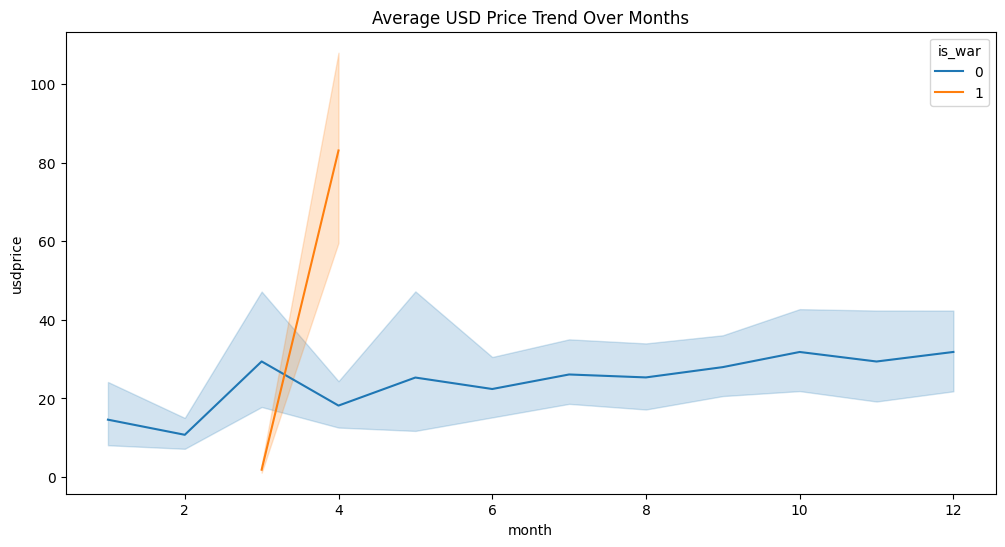

In [20]:
plt.figure(figsize=(12,6))
sns.lineplot(data=data_final, x='month', y='usdprice', hue='is_war', estimator='mean')
plt.title("Average USD Price Trend Over Months")
plt.show()

### 📈 Impact of Conflict on Monthly Price Trends

* **Stability in Peace:** During peaceful periods (`is_war = 0`), the average USD price remains consistently stable with minimal fluctuations across all months.
* **Aggressive Inflation in War:** The onset of conflict (`is_war = 1`) triggers a massive, exponential spike in food prices. Within a few months, average prices surged from under **$10** to over **$80**.
* **Price Disparity:** There is a clear decoupling of prices during war. The "War" trend line shows extreme volatility and a significantly higher price floor compared to peaceful times.
* **Conclusion:** The `is_war` feature is a primary driver of price action in this dataset, and the model must account for this sudden variance to predict future prices accurately.

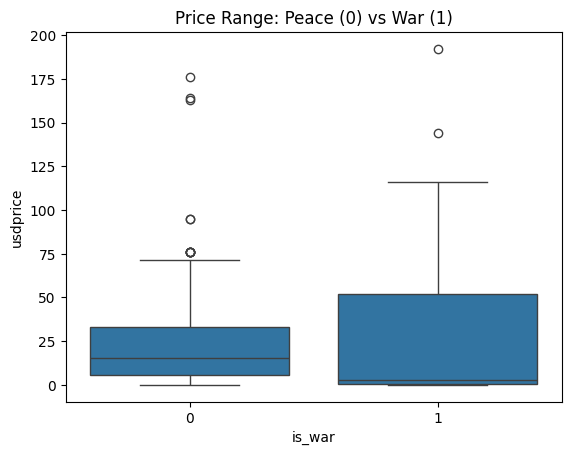

In [21]:
sns.boxplot(data=data_final, x='is_war', y='usdprice')
plt.title("Price Range: Peace (0) vs War (1)")
plt.show()

### 📦 Box Plot Analysis: Price Distribution under Conflict

* **Higher Price Floor:** The median price during war (`is_war=1`) is significantly higher than during peace, confirming that conflict causes a systemic rise in food costs.
* **Increased Volatility:** The much larger Interquartile Range (IQR) during war periods indicates high price variance. This suggests that some commodities are impacted by inflation far more severely than others.
* **Extended Price Ceiling:** The upper whisker in the war distribution reaches nearly **$150**, compared to a much lower threshold during peace. This highlights the disappearance of affordable pricing structures during crises.
* **Outlier Interpretation:** While peace-time has several extreme outliers, the war-time distribution absorbs high prices as the "new normal," showing that what was once an extreme price becomes common during conflict.

In [22]:
data_final.to_csv('data/Final_data.csv', index=False)

**Saving the label**

In [23]:
import pickle
import os 

output_dir = os.path.join("..", "artifacts")
os.makedirs(output_dir, exist_ok=True)

encoder_path = os.path.join(output_dir, "label_encoders.pkl")

with open(encoder_path, "wb") as file_obj:
    pickle.dump(encoder_dict, file_obj)

print(f"All encoders saved successfully at: {encoder_path}")

All encoders saved successfully at: ..\artifacts\label_encoders.pkl


# Now We can Train the Model with this Dataset